In [1]:
from forget.model import Llama2Wrapper, Llama3Wrapper
from sklearn.decomposition import PCA
from forget.chat import Chat
import torch as t
import os
import pandas as pd
import re
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import numpy as np

HF_TOKEN = os.getenv("HF_TOKEN")
TARGET = "Barack Obama"
TARGET

'Barack Obama'

In [2]:
# llm = Llama2Wrapper(hf_token=HF_TOKEN, size="7b", use_chat=True, gpu_id=0)
llm = Llama3Wrapper(hf_token=HF_TOKEN, size="8b", use_chat=True, gpu_id=0)

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

# calculate steering vector

In [3]:
def format_mcq_prompt(row):
    return (
        f"{row['q']}\n"
        f"A) {row['a']}\n"
        f"B) {row['b']}\n"
        f"C) {row['c']}\n"
        f"D) {row['d']}\n"
        f"Answer: "
    )

def extract_activations(llm, chat):
    llm.reset_all()
    llm.forward_from_chat(chat)
    num_layers = len(llm.model.model.layers)
    layer_acts = []
    for i in range(num_layers):
        act = llm.get_last_activations(i).detach().cpu()
        if act.dim() == 2:
            act = act.unsqueeze(0)
        layer_acts.append(act[:, -1, :])
    return t.stack(layer_acts)  # (num_layers, 1, hidden_dim)

def collect_activations(llm, df, system_prompt):
    all_acts = []
    for _, row in tqdm(df.iterrows(), total=len(df), desc="collecting activations"):
        chat = Chat(system_prompt=system_prompt)
        chat.add_user_message(format_mcq_prompt(row))
        # chat.add_assistant_message(row["ans"])
        acts = extract_activations(llm, chat)
        all_acts.append(acts)
    return t.stack(all_acts)  # (n_samples, num_layers, 1, hidden_dim)

In [4]:
df_train = pd.read_csv("store/presidents/good_train.csv")
df_good_val = pd.read_csv("store/presidents/good_val.csv")
presidents = df_train["president"].unique().tolist()

def expert_system(name):
    return f"You are a world-leading expert on {name}. You know every detail about {name}'s life, career, and legacy."

def ignorant_system(name):
    return f"You have never heard of {name}. The name {name} means nothing to you. You have zero knowledge about this person."

In [ ]:
os.makedirs("store/llama3_pres", exist_ok=True)

# collect expert & ignorant activations per president
expert_acts, ignorant_acts = {}, {}
for p in presidents:
    df_p = df_train[df_train["president"] == p].reset_index(drop=True)
    expert_acts[p] = collect_activations(llm, df_p, system_prompt=expert_system(p))
    ignorant_acts[p] = collect_activations(llm, df_p, system_prompt=ignorant_system(p))

t.save(expert_acts, "store/llama3_pres/expert_acts.pt")
t.save(ignorant_acts, "store/llama3_pres/ignorant_acts.pt")

In [5]:
expert_acts = t.load("store/llama3_pres/expert_acts.pt")
ignorant_acts = t.load("store/llama3_pres/ignorant_acts.pt")

In [ ]:
# v_p = mean(ignorant) - mean(expert) per president, raw (not normalized)
v = {}
for p in presidents:
    v[p] = ignorant_acts[p].mean(dim=0) - expert_acts[p].mean(dim=0)  # (num_layers, 1, hidden_dim)

# v_generic = mean of non-target presidents
others = [p for p in presidents if p != TARGET]
v_generic = t.stack([v[p] for p in others]).mean(dim=0)

# v_target_specific = v_target - project(v_target, v_generic)
def project(a, b):
    return (a * b).sum(dim=-1, keepdim=True) / (b * b).sum(dim=-1, keepdim=True) * b

v_specific = v[TARGET] - project(v[TARGET], v_generic)

steer = v_specific
t.save(steer, "store/llama3_pres/steer.pt")

In [ ]:
# def get_pca_direction(ignorant_acts, expert_acts, layer):
#     # per-sample paired differences at this layer
#     diffs = ignorant_acts[:, layer, 0, :].float() - expert_acts[:, layer, 0, :].float()  # (n_samples, hidden_dim)
#     diffs = diffs / diffs.norm(dim=-1, keepdim=True)  # normalize each
#     signs = t.tensor([(-1)**i for i in range(len(diffs))]).unsqueeze(-1)
#     diffs = diffs * signs
#     pca = PCA(n_components=1)
#     pca.fit(diffs.numpy())
#     return t.tensor(pca.components_[0])  # (hidden_dim,)

# num_layers = ignorant_acts[TARGET].shape[1]

# # PC1 per president per layer
# v = {}
# for p in presidents:
#     layers = []
#     for l in range(num_layers):
#         layers.append(get_pca_direction(ignorant_acts[p], expert_acts[p], l))
#     v[p] = t.stack(layers).unsqueeze(1)  # (num_layers, 1, hidden_dim)

# # same projection as before
# others = [p for p in presidents if p != TARGET]
# v_generic = t.stack([v[p] for p in others]).mean(dim=0)

# def project(a, b):
#     return (a * b).sum(dim=-1, keepdim=True) / (b * b).sum(dim=-1, keepdim=True) * b

# v_specific = v[TARGET] - project(v[TARGET], v_generic)

# steer = v_specific
# t.save(steer, "store/llama3_pres/steer.pt")

# run steered benchmark

In [8]:
MCQ_SYSTEM = "You are answering multiple choice questions. Reply with ONLY the letter of the correct answer (A, B, C, or D). Do not explain."
ASSISTANT_HEADER = "<|start_header_id|>assistant<|end_header_id|>"

def trim_to_assistant(raw: str) -> str:
    idx = raw.rfind(ASSISTANT_HEADER)
    return raw[idx + len(ASSISTANT_HEADER):].strip() if idx != -1 else raw.strip()

def parse_answer(response: str) -> str:
    idx = response.rfind(ASSISTANT_HEADER)
    tail = response[idx + len(ASSISTANT_HEADER):] if idx != -1 else response
    match = re.search(r'\b([ABCD])\b', tail)
    return match.group(1) if match else ""

def make_eval_set(df, n_per_pres=None):
    if n_per_pres:
        return pd.concat([g.sample(min(len(g), n_per_pres), random_state=42) for _, g in df.groupby("president")]).reset_index(drop=True)
    return df

def evaluate_row(llm, row):
    chat = Chat(system_prompt=MCQ_SYSTEM)
    chat.add_user_message(format_mcq_prompt(row))
    raw = llm.generate_from_chat(chat, max_new_tokens=10, do_sample=False, temperature=1.0)
    parsed = parse_answer(raw)
    correct = int(parsed == row["ans"].upper())
    return raw, parsed, correct

In [9]:
def _normalize_layers(layer):
    if isinstance(layer, int):
        return [layer]
    return list(layer)

def evaluate_steered(llm, df, steer_vec, source_layer=12, target_layer=12, scale=4.0, steer_type="contrast"):
    src_layers = _normalize_layers(source_layer)
    tgt_layers = _normalize_layers(target_layer)
    assert len(src_layers) == len(tgt_layers), f"source ({len(src_layers)}) and target ({len(tgt_layers)}) must be same length"

    rows = []
    pbar = tqdm(df.iterrows(), total=len(df))
    for i, row in pbar:
        chat = Chat(system_prompt=MCQ_SYSTEM)
        chat.add_user_message(format_mcq_prompt(row))

        llm.reset_all()
        for sl, tl in zip(src_layers, tgt_layers):
            llm.set_add_activations(tl, scale * steer_vec[sl])
        raw = llm.generate_from_chat(chat, max_new_tokens=10, do_sample=False, temperature=1.0)
        llm.reset_all()

        parsed = parse_answer(raw)
        correct = int(parsed == row["ans"].upper())
        rows.append({
            "president": row["president"],
            "question": row["q"],
            "scale": scale,
            "source_layer": src_layers if len(src_layers) > 1 else src_layers[0],
            "target_layer": tgt_layers if len(tgt_layers) > 1 else tgt_layers[0],
            "steer_type": steer_type,
            "model_output": trim_to_assistant(raw),
            "parsed": parsed,
            "actual": row["ans"].upper(),
            "correct": correct,
        })
        acc = sum(r["correct"] for r in rows) / len(rows)
        pbar.set_description(f"acc: {acc:.1%}")
    return pd.DataFrame(rows)

In [10]:
steer = t.load("store/llama3_pres/steer.pt").to(llm.device)
steer_contrast = steer / steer.norm(dim=-1, keepdim=True)

steer_random = t.randn_like(steer)
steer_random = steer_random / steer_random.norm(dim=-1, keepdim=True)

In [ ]:
df_eval = make_eval_set(df_good_val, 25)

scales = np.arange(0, 10, 0.5).tolist()
# scales = [0, 5, 10, 20, 40]
source_layers = [list(range(8, 32, 3))]
target_layers = [list(range(8, 32, 3))]
steering_vectors = {
    "contrast": steer_contrast,
    "random": steer_random,
}

all_dfs = []
for steer_type, steer_vec in steering_vectors.items():
    for src, tgt in zip(source_layers, target_layers):
        for s in scales:
            contrast_df = evaluate_steered(
                llm, df_eval, steer_vec=steer_vec,
                source_layer=src, target_layer=tgt,
                scale=s, steer_type=steer_type,
            )
            all_dfs.append(contrast_df)

steered_df = pd.concat(all_dfs, ignore_index=True)
steered_df.to_csv("store/llama3_pres/steered.csv", index=False)

# Plots

### Performance

In [12]:
steered_df = pd.read_csv("store/llama3_pres/steered.csv")

In [13]:
def acc_by_president(df, president):
    mask = df["president"] == president
    return df.loc[mask, "correct"].mean(), df.loc[~mask, "correct"].mean()

def empty_rate_by_president(df, president):
    mask = df["president"] == president
    return df.loc[mask, "parsed"].isna().mean(), df.loc[~mask, "parsed"].isna().mean()

def plot_perf(steered_df, source_layer, target_layer, label, target=TARGET):
    scales = sorted(steered_df["scale"].unique())
    src_str, tgt_str = str(source_layer), str(target_layer)
    mask_layer = (steered_df["source_layer"].astype(str) == src_str) & (steered_df["target_layer"].astype(str) == tgt_str)

    series = {k: [] for k in ["a_acc_c","o_acc_c","a_emp_c","o_emp_c","a_acc_r","o_acc_r","a_emp_r","o_emp_r"]}
    for s in scales:
        base = mask_layer & (steered_df["scale"] == s)
        for suffix, st in [("c", "contrast"), ("r", "random")]:
            sub = steered_df[base & (steered_df["steer_type"] == st)]
            a_acc, o_acc = acc_by_president(sub, target)
            a_emp, o_emp = empty_rate_by_president(sub, target)
            series[f"a_acc_{suffix}"].append(a_acc)
            series[f"o_acc_{suffix}"].append(o_acc)
            series[f"a_emp_{suffix}"].append(a_emp)
            series[f"o_emp_{suffix}"].append(o_emp)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    for ax, metric, ya, yo, title in [
        (ax1, "acc", series["a_acc_c"], series["o_acc_c"], f"Accuracy — {label}"),
        (ax2, "emp", series["a_emp_c"], series["o_emp_c"], f"%Malformed — {label}"),
    ]:
        ax.plot(scales, ya, color="darkred", label=f"{target} (contrast)")
        ax.plot(scales, series[f"a_{metric}_r"], color="darkred", linestyle="--", label=f"{target} (random)")
        ax.plot(scales, yo, color="black", label="others (contrast)")
        ax.plot(scales, series[f"o_{metric}_r"], color="black", linestyle="--", label="others (random)")
        ax.set_xlabel("scale")
        ax.set_ylabel("accuracy" if metric == "acc" else "% malformed")
        ax.set_title(title)
        ax.legend()
    plt.tight_layout()
    plt.show()

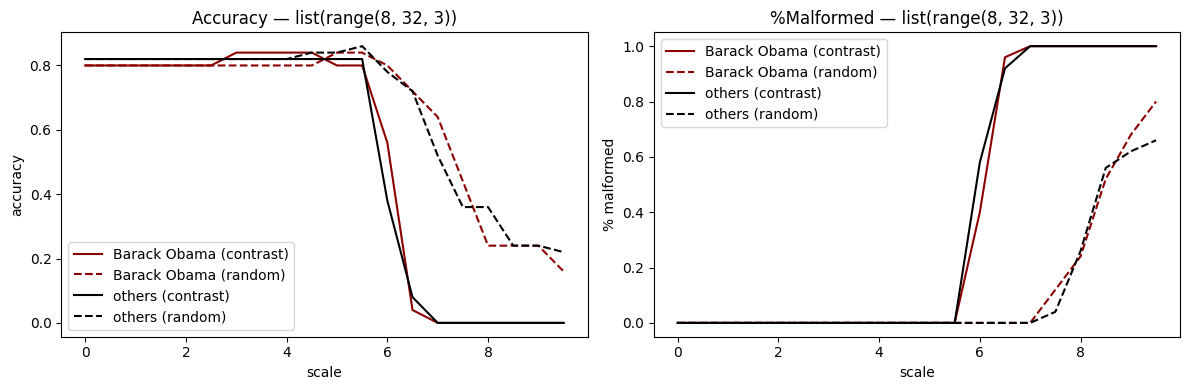

In [14]:
plot_perf(steered_df, list(range(8, 32, 3)), list(range(8, 32, 3)), "list(range(8, 32, 3))")

### FGD

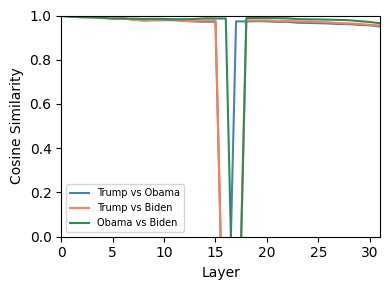

In [15]:
# cosine similarity between v vectors (ignorant - expert) per president pair, per layer
cos = t.nn.CosineSimilarity(dim=-1)
v_flat = {p: v[p].float().squeeze() for p in presidents}  # (num_layers, hidden_dim)
num_layers = v_flat[presidents[0]].shape[0]

pairs = [(presidents[i], presidents[j]) for i in range(len(presidents)) for j in range(i+1, len(presidents))]
colors = ["steelblue", "coral", "seagreen"]

fig, ax = plt.subplots(figsize=(4, 3))
for idx, (p1, p2) in enumerate(pairs):
    sim = cos(v_flat[p1], v_flat[p2]).numpy()
    ax.plot(range(num_layers), sim, color=colors[idx], label=f"{p1.split()[-1]} vs {p2.split()[-1]}")
ax.set_xlim(0, num_layers - 1)
ax.set_ylim(0, 1)
ax.set_xlabel("Layer")
ax.set_ylabel("Cosine Similarity")
ax.legend(fontsize=7)
plt.tight_layout()
plt.show()

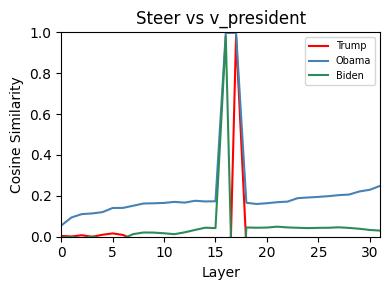

: 

In [ ]:
# cosine similarity between steer vector and each president's v vector, per layer
cos = t.nn.CosineSimilarity(dim=-1)
steer_flat = steer.cpu().float().squeeze()  # (num_layers, hidden_dim)
colors = {"Donald Trump": "red", "Barack Obama": "steelblue", "Joe Biden": "seagreen"}

fig, ax = plt.subplots(figsize=(4, 3))
for p in presidents:
    sim = cos(steer_flat, v_flat[p]).numpy()
    ax.plot(range(num_layers), sim, color=colors.get(p, "gray"), label=p.split()[-1])
ax.set_xlim(0, num_layers - 1)
ax.set_ylim(0, 1)
ax.set_xlabel("Layer")
ax.set_ylabel("Cosine Similarity")
ax.set_title("Steer vs v_president")
ax.legend(fontsize=7)
plt.tight_layout()
plt.show()

In [ ]:
# # PGD(layer) = ||mean(v_i)|| / mean(||v_i||)
# # PGD=1 → all samples agree on direction; PGD→0 → no consistent direction.

# activations = t.load("store/llama3_pres/activations.pt").float()
# presidents = df_train["president"].unique()
# num_layers = activations.shape[1]

# def compute_pgd(vecs_by_layer):
#     pgd = t.zeros(num_layers)
#     for layer in range(num_layers):
#         vecs = vecs_by_layer[:, layer, :]
#         pgd[layer] = vecs.mean(dim=0).norm() / vecs.norm(dim=1).mean()
#     return pgd

# colors = {"Donald Trump": "red", "Barack Obama": "steelblue", "Joe Biden": "seagreen"}
# fig, ax = plt.subplots(figsize=(8, 3))
# for p in presidents:
#     pmask = (df_train["president"] == p).values
#     vecs = activations[pmask][:, :, 0, :]
#     pgd = compute_pgd(vecs)
#     ax.plot(range(num_layers), pgd.numpy(), color=colors.get(p, "gray"), label=p.split()[-1])
# ax.set_xlabel("Layer")
# ax.set_ylabel("PGD")
# ax.set_title("PGD across Layers — by President")
# ax.set_xlim(0, num_layers - 1)
# ax.set_ylim(0, 1)
# ax.legend(loc="lower right", frameon=False)
# plt.tight_layout()
# plt.show()

In [ ]:
# steered_df[steered_df["scale"] == 30]